In [7]:
#1
import threading
import time

saldo = 1_000_000
lock = threading.Lock()

def operasi_tanpa_lock():
    global saldo
    for _ in range(10_000):
        temp = saldo
        temp -= 1
        temp += 1
        saldo = temp

def operasi_dengan_lock():
    global saldo
    for _ in range(10_000):
        with lock:
            saldo -= 1
            saldo += 1

# --- Pengujian Tanpa Lock ---
saldo = 1_000_000
threads = [threading.Thread(target=operasi_tanpa_lock) for _ in range(10)]
for t in threads: t.start()
for t in threads: t.join()
print(f"Saldo Akhir (Tanpa Lock) : {saldo}")

# --- Pengujian Dengan Lock ---
saldo = 1_000_000
threads = [threading.Thread(target=operasi_dengan_lock) for _ in range(10)]
for t in threads: t.start()
for t in threads: t.join()
print(f"Saldo Akhir (Dengan Lock): {saldo}")

Saldo Akhir (Tanpa Lock) : 1000000
Saldo Akhir (Dengan Lock): 1000000


In [8]:
#2
import queue
import threading
import time

q = queue.Queue()
NUM_CONSUMERS = 3

def producer():
    for i in range(10):
        item = f"Data-{i}"
        q.put(item)
        print(f"[Producer] Menghasilkan: {item}")
        time.sleep(0.1)
    
    # Kirim sinyal None untuk SETIAP consumer
    for _ in range(NUM_CONSUMERS):
        q.put(None)
    print("[Producer] Selesai mengirim data.")

def consumer(consumer_id):
    while True:
        item = q.get()
        if item is None:
            print(f"[Consumer-{consumer_id}] Menerima sinyal berhenti (None).")
            q.task_done()
            break
        print(f"[Consumer-{consumer_id}] Memproses: {item}")
        time.sleep(0.2)
        q.task_done()

# Jalankan Thread
p_thread = threading.Thread(target=producer)
c_threads = [threading.Thread(target=consumer, args=(i+1,)) for i in range(NUM_CONSUMERS)]

p_thread.start()
for c in c_threads:
    c.start()

p_thread.join()
for c in c_threads:
    c.join()

print("Seluruh proses Producer-Consumer selesai.")

[Producer] Menghasilkan: Data-0
[Consumer-1] Memproses: Data-0
[Producer] Menghasilkan: Data-1
[Consumer-2] Memproses: Data-1
[Producer] Menghasilkan: Data-2
[Consumer-3] Memproses: Data-2
[Producer] Menghasilkan: Data-3[Consumer-1] Memproses: Data-3

[Producer] Menghasilkan: Data-4
[Consumer-2] Memproses: Data-4
[Producer] Menghasilkan: Data-5
[Consumer-3] Memproses: Data-5
[Producer] Menghasilkan: Data-6[Consumer-1] Memproses: Data-6

[Producer] Menghasilkan: Data-7
[Consumer-2] Memproses: Data-7
[Producer] Menghasilkan: Data-8
[Consumer-3] Memproses: Data-8
[Producer] Menghasilkan: Data-9[Consumer-1] Memproses: Data-9

[Producer] Selesai mengirim data.
[Consumer-2] Menerima sinyal berhenti (None).
[Consumer-3] Menerima sinyal berhenti (None).
[Consumer-1] Menerima sinyal berhenti (None).
Seluruh proses Producer-Consumer selesai.


Memulai simulasi eksekusi...
max_workers =  2 | Waktu: 1.26 detik
max_workers =  4 | Waktu: 0.66 detik
max_workers =  8 | Waktu: 0.36 detik
max_workers = 16 | Waktu: 0.20 detik


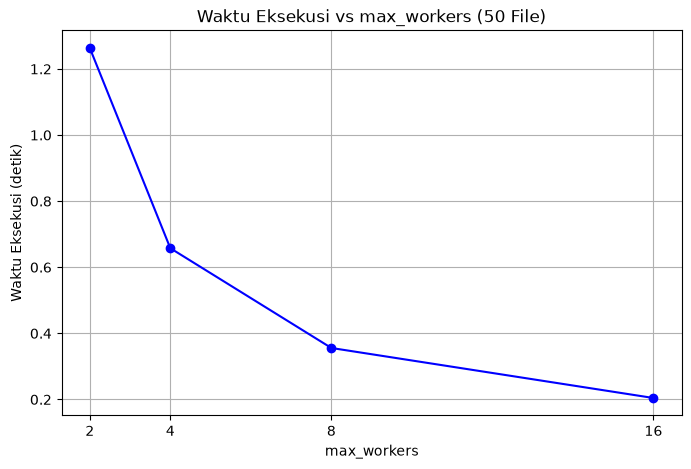

In [9]:
#3
import time
from concurrent.futures import ThreadPoolExecutor
import matplotlib.pyplot as plt

def download_file_simulation(file_id):
    time.sleep(0.05)
    return f"File_{file_id} selesai"

files = list(range(50))
workers_list = [2, 4, 8, 16]
execution_times = []

print("Memulai simulasi eksekusi...")

for max_workers in workers_list:
    start_time = time.time()
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        results = list(executor.map(download_file_simulation, files))
    elapsed_time = time.time() - start_time
    execution_times.append(elapsed_time)
    print(f"max_workers = {max_workers:2d} | Waktu: {elapsed_time:.2f} detik")

plt.figure(figsize=(8, 5))
plt.plot(workers_list, execution_times, marker="o", color="b", linestyle="-")
plt.title("Waktu Eksekusi vs max_workers (50 File)")
plt.xlabel("max_workers")
plt.ylabel("Waktu Eksekusi (detik)")
plt.xticks(workers_list)
plt.grid(True)
plt.show()

In [ ]:
#4
Skenario threading membantu (I/O-Bound):   
Aplikasi web scraper yang mengunduh ratusan halaman web secara bersamaan. Threading sangat efektif karena saat satu thread menunggu respon server (I/O wait), thread lain dapat mengeksekusi request baru.
    Skenario threading TIDAK membantu (CPU-Bound)
Aplikasi pemrosesan gambar/video (seperti konversi frame atau perataan filter) atau ekstraksi features AI. Karena Python dibatasi oleh GIL (Global Interpreter Lock), threading tidak dapat menggunakan multi-core CPU secara paralel untuk tugas komputasi berat, sehingga multiprocessing lebih tepat digunakan.